## ABC (Pareto) Inventory Analysis

### Objective
Identify high-value products contributing the most revenue to prioritize demand forecasting and inventory optimization efforts.

ABC analysis classifies products based on their cumulative revenue contribution:
- **A:** Top ~80% of cumulative revenue (highest priority)
- **B:** Next ~15% of cumulative revenue
- **C:** Remaining ~5% of cumulative revenue

#

In [1]:
import pandas as pd 
import numpy as np 

In [7]:
df=pd.read_csv("data used/processed_supply_chain.csv")

In [9]:
#aggregating revenue by sku:
abc= df.groupby('sku_id')[['revenue']].sum().reset_index().sort_values('revenue', ascending=False)


#revenue %
abc['revenue%']= (abc['revenue']/abc['revenue'].sum())*100

#cumulative revenue %
abc['cumulative%']= abc['revenue%'].cumsum()

abc.head()

,sku_id,revenue,revenue%,cumulative%
31,SKU_38,1057641.51,3.164096,3.164096
34,SKU_40,923848.62,2.763834,5.927931
2,SKU_11,888870.07,2.659191,8.587122
42,SKU_48,846494.22,2.532417,11.119538
24,SKU_31,827241.09,2.474818,13.594357


In [10]:
#classification rules:

def classify(x):
    if x<=80:
        return 'A'
    elif x<=95:
        return 'B'
    else:
        return 'C'
    
abc['category']= abc['cumulative%'].apply(classify)
print(abc['category'].value_counts())

category
A    37
B     9
C     4
Name: count, dtype: int64


In [11]:
abc.head()

,sku_id,revenue,revenue%,cumulative%,category
31,SKU_38,1057641.51,3.164096,3.164096,A
34,SKU_40,923848.62,2.763834,5.927931,A
2,SKU_11,888870.07,2.659191,8.587122,A
42,SKU_48,846494.22,2.532417,11.119538,A
24,SKU_31,827241.09,2.474818,13.594357,A


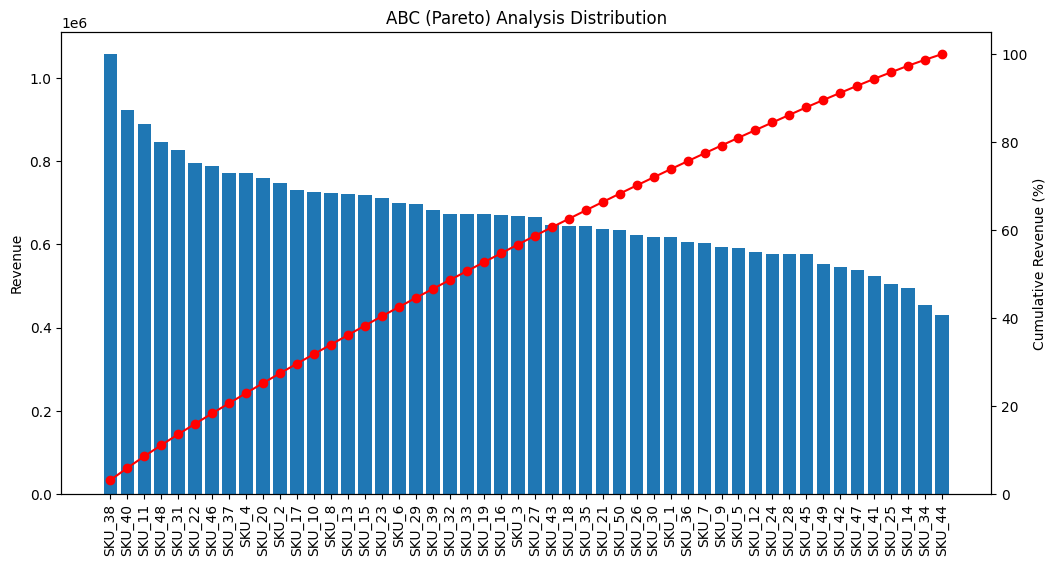

In [13]:
#plotting Pareto chart visualisation:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(abc['sku_id'], abc['revenue'])
ax1.set_ylabel("Revenue")
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(abc['sku_id'], abc['cumulative%'], color='red',marker='o')
ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0,105)

plt.title("ABC (Pareto) Analysis Distribution")
plt.show()

#### IMPORTANT CONCLUSIONS:

- since the distribution doesn't exhibit strong pareto distribution so we can't limit demand forecasting to just A-category SKUs

- instead, we'd forecast all 50 SKUs using one global model.

- so even though certain SKUs outperform others, revenue is relatively evenly distributed across the product portfolio.Hence, forecasting will be performed for all SKUs rather than focusing only on a small subset
